In [ ]:
import numpy as np
import scipy as sp
import qutip as qt
import pandas as pd

np.set_printoptions(precision=4, suppress=True ,linewidth=np.inf, floatmode='fixed')


import matplotlib.pyplot as plt

: 

## Parameters 
let k_b = 1

**main parameters** : $\lambda$, $\theta$ 

**fixed parameters** : $\epsilon$, g(coupling strengh), $\beta$ , real time interval

In [69]:
lamb = np.linspace(0,1,50)
theta = np.linspace(0,1,50)

eps = 2

beta_a = 1
beta_b = 3
beta = 1.5
t = np.linspace(0,1,1000)


## Matrices

Basis : Fock basis

**Hamiltonian** : 4*4 Matrix

**Bell states** : 4*4 Matrix

#### Create Hamiltonian

In [70]:
mat_crea2 = np.array([[0,0],[1,0]])
mat_anni2 = np.array([[0,1],[0,0]]) 
mat_id2 = np.identity(2)

diag_Ham = np.kron(mat_id2,[[0,0],[0,1]])
diag_Ham += np.kron([[0,0],[0,1]],mat_id2)

diag_Ham *= eps

Ham = diag_Ham

##### Bellstates

In [71]:
# 1. Ket 벡터 생성
ket_phi_plus = qt.bell_state('00') # (|00> + |11>) / sqrt(2)
ket_psi_minus = qt.bell_state('11') # (|01> - |10>) / sqrt(2)

# 2. 밀도 행렬(Density Matrix)로 변환 (|psi><psi|)
dm_phi_plus = qt.ket2dm(ket_phi_plus)
dm_psi_minus = qt.ket2dm(ket_psi_minus)

# 3. [중요] NumPy 배열로 변환 (사용자님 코드와 호환되게)
mat_phi_plu = dm_phi_plus.full()
mat_psi_min = dm_psi_minus.full()

print("Shape:", mat_phi_plu.shape) # (4, 4) 여야 함

Shape: (4, 4)


#### Matrix calculation function

In [73]:
def Gibb(beta,mat):
    Gib = sp.linalg.expm(-beta * mat)
    Part_func = np.trace(Gib)

    return Gib/Part_func

In [74]:
def Tra_A(Mat,n):
    if n == 0:
        tens = Mat.reshape(2,2,2,2)
        trac = np.einsum('ijlj->il', tens)
    else:
        tens = Mat.reshape(2,2,n,2,2,n)
        trac = np.einsum('ijkljk->il', tens)
    return trac


def Tra_B(Mat,n):
    if n == 0:
        tens = Mat.reshape(2,2,2,2)
        trac = np.einsum('ijil->jl', tens)
    else:
        tens = Mat.reshape(2,2,n,2,2,n)
        trac = np.einsum('ijkilk->jl', tens)
    return trac

# System A: B의 인덱스를 Trace (B_row와 B_col이 같아야 함)
H_b = Tra_A(Gibb(beta_a,Ham),0)

# System B: A의 인덱스를 Trace (A_row와 A_col이 같아야 함)
H_a = Tra_B(Gibb(beta_b,Ham),0)

In [75]:
print(Gibb(beta,Ham))
print(H_a)

[[0.9074 0.0000 0.0000 0.0000]
 [0.0000 0.0452 0.0000 0.0000]
 [0.0000 0.0000 0.0452 0.0000]
 [0.0000 0.0000 0.0000 0.0022]]
[[0.9975 0.0000]
 [0.0000 0.0025]]


#### Calculate $\rho_{AB}(\lambda,\theta)$

In [76]:
def Cal_rho(lamb_index,theta_index):
    rho = (1-lamb[lamb_index]- theta[theta_index])*np.kron(H_a,H_b) + lamb[lamb_index] * mat_phi_plu + theta[theta_index] * mat_psi_min
    return rho

In [77]:
np.trace(Cal_rho(42,2))

np.complex128(1.0000000000000002+0j)

#### Unitary design

Optimal unit (Theorem 1)

In [ ]:
def get_optimal_unitary(rho_AB, HAM, tol=1e-9):
    """
    논문의 Theorem 1에 따라 로컬 에너지 E_A를 최소화하는 최적의 Unitary U_*를 반환합니다.
    
    Args:
        rho_AB (np.ndarray): 초기 상태 밀도 행렬 (d_A * d_B, d_A * d_B)
        H_A (np.ndarray): 시스템 A의 해밀토니안 (d_A, d_A)
        H_B (np.ndarray): 시스템 B의 해밀토니안 (d_B, d_B)
        tol (float): 에너지 준위가 같다고 판단할 허용 오차
        
    Returns:
        U_opt (np.ndarray): 최적 유니터리 행렬
    """
    # 1. 차원 확인 및 전체 해밀토니안 구성
    dim_tot = HAM.shape[0]

    H_tot = HAM
    
    # 2. 전체 해밀토니안 대각화하여 에너지 고유기저 찾기
    eigvals_tot, eigvecs_tot = np.linalg.eigh(H_tot)
    
    # 3. 에너지가 같은 부분공간(Degenerate Subspaces)으로 그룹화
    # np.unique 등을 사용해 그룹 인덱싱
    # round를 통해 수치적 오차 보정
    energies_rounded = np.round(eigvals_tot / tol) * tol
    unique_energies = np.unique(energies_rounded)
    
    U_opt = np.zeros((dim_tot, dim_tot), dtype=complex)
    
    for E in unique_energies:
        # 해당 에너지 E를 가지는 인덱스들 찾기
        indices = np.where(np.abs(energies_rounded - E) < tol)[0]
        
        if len(indices) == 0:
            continue
            
        # 부분공간의 기저 벡터들 (Global Energy Eigenbasis)
        subspace_basis = eigvecs_tot[:, indices] # shape: (dim_tot, block_dim)
        
        # 4. 블록 내의 밀도 행렬(rho) 대각화
        # rho_block = P^dag @ rho @ P
        rho_block = subspace_basis.conj().T @ rho_AB @ subspace_basis
        
        p_nu, v_rho = np.linalg.eigh(rho_block)
        
        # 확률(p_nu)은 내림차순 정렬 (큰 확률 -> 작은 확률)
        # eigh는 오름차순으로 반환하므로 뒤집음
        sorted_p_indices = np.argsort(p_nu)[::-1]
        p_nu_sorted = p_nu[sorted_p_indices]
        v_rho_sorted = v_rho[:, sorted_p_indices]
        
        # |phi_n>: 전체 힐베르트 공간에서 rho의 고유상태들
        phi_n_states = subspace_basis @ v_rho_sorted
        
        # 5. 블록 내의 H_A 대각화 (Local Energy Sorting)
        # H_A_block = P^dag @ (H_A x I) @ P
        H_A_block = subspace_basis.conj().T @ H_A_tot @ subspace_basis
        
        e_A_vals, v_HA = np.linalg.eigh(H_A_block)
        
        # A의 에너지는 오름차순 정렬 (작은 에너지 -> 큰 에너지)
        # 목적: 확률이 큰 상태(High Prob)를 에너지가 작은 상태(Low Energy)로 보냄 -> 에너지 최소화
        sorted_e_indices = np.argsort(e_A_vals) # Default is ascending
        e_A_sorted = e_A_vals[sorted_e_indices]
        v_HA_sorted = v_HA[:, sorted_e_indices]
        
        # |epsilon_n>: 전체 힐베르트 공간에서 정렬된 에너지 기저들
        epsilon_n_states = subspace_basis @ v_HA_sorted
        
        # 6. 부분공간 유니터리 구성: sum |epsilon><phi|
        # U_sub = sum_n |epsilon_n^nu> <phi_n^nu|
        U_sub = epsilon_n_states @ phi_n_states.conj().T
        
        U_opt += U_sub
        
    return U_opt

Optimal unitary test

In [84]:
U_opt = get_optimal_unitary(Cal_rho(1,1),H_a,H_b).real

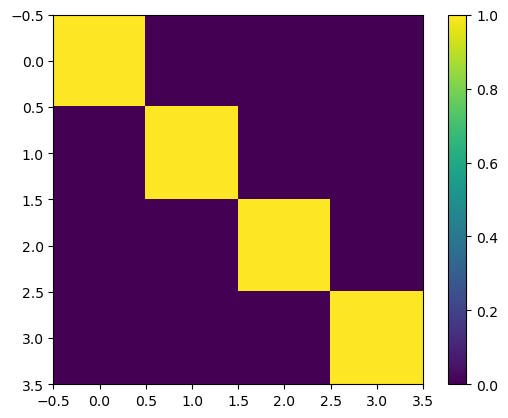

In [85]:
plt.imshow(U_opt)
plt.colorbar()
plt.show()

In [86]:
Cal_rho(1,1)

array([[ 0.8530+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0102+0.0000j],
       [ 0.0000+0.0000j,  0.1243+0.0000j, -0.0102+0.0000j,  0.0000+0.0000j],
       [ 0.0000+0.0000j, -0.0102+0.0000j,  0.0123+0.0000j,  0.0000+0.0000j],
       [ 0.0102+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0105+0.0000j]])

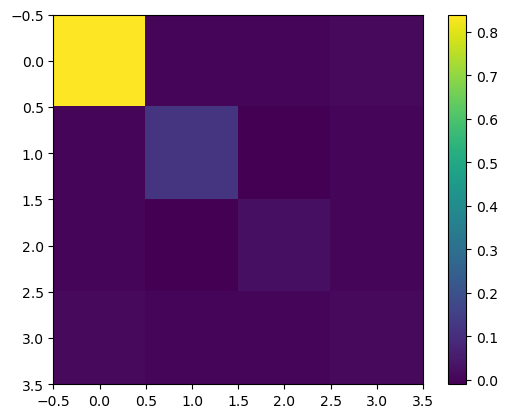

In [27]:
plt.imshow((U_opt @ Cal_rho(1,1) @ U_opt.conj().T).real)
plt.colorbar()
plt.show()

#### Calculate $\sigma_{AB}$

In [87]:
def Cal_sig(li,tl):
    #rho_AB를 sigma_AB로 계산하는 함수
    sig = get_optimal_unitary(Cal_rho(li,tl),H_a,H_b).real @ Cal_rho(li,tl) @ np.conj(get_optimal_unitary(Cal_rho(li,tl),H_a,H_b).real).T
    return sig

In [31]:
sigma = Cal_sig(1,1)

#### Calculate $E(\sigma_{A}')-E(\rho_A)$

In [94]:
dataset = np.zeros((len(theta),len(lamb)))

for i in range(len(theta)):
    for j in range(len(lamb)):
        Eprim_final_trace = Tra_B(Cal_sig(i,j),0)
        Eprim_final = np.trace(Gibb(beta_a,H_a) @ Eprim_final_trace)

        E_final = np.trace(Gibb(beta_a,H_a) @ Tra_B(Cal_rho(i,j),0)).real
        dataset[i][j] = E_final-Eprim_final

C:\Users\128kbps\AppData\Local\Temp\ipykernel_66260\1301766662.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  dataset[i][j] = E_final-Eprim_final


In [95]:
np.savetxt('./cv2.txt',dataset)